In [ ]:
from accelforge import Spec
from accelforge.frontend.arch import (
    Arch,
    Memory,
    Action,
    Tensors,
    Compute,
    Container,
    Spatial,
    Comparison,
)
from accelforge.frontend.workload import (
    Workload,
    Einsum,
    TensorAccess,
)

from math import ceil

# =========================================================
# CONSTANTS
# =========================================================

CLOCK_HZ = 1e9

BYTES_PER_ACCESS = 256
BITS_PER_ACCESS = BYTES_PER_ACCESS * 8

# Normalized per-access energy and latency hierarchy.
# Latency ratios are represented through inverse throughput.
OUTPUT_REG_ENERGY = 0.2
ACTIVATION_REG_ENERGY = 1.0
WEIGHT_REG_ENERGY = 1.0
W_ENERGY = 2.0
AO_ENERGY = 4.0
DRAM_ENERGY = 400.0

OUTPUT_REG_THROUGHPUT = CLOCK_HZ * 5
ACTIVATION_REG_THROUGHPUT = CLOCK_HZ
WEIGHT_REG_THROUGHPUT = CLOCK_HZ
W_THROUGHPUT = CLOCK_HZ / 2
AO_THROUGHPUT = CLOCK_HZ / 4
DRAM_THROUGHPUT = CLOCK_HZ / 400


# Size of ONE AO entry
AO_ENTRY_SIZE_BYTES = int(0.35 * 1024**2)

W_SIZE_BYTES = int(0.10 * 1024**2)


# =========================================================
# DRAM
# =========================================================

dram = Memory(
    name="DRAM",

    size=512 * 1024**2 * 8,
    bits_per_action=BITS_PER_ACCESS,

    area=0,
    leak_power=0,

    actions=[
        Action(
            name="read",
            throughput=DRAM_THROUGHPUT,
            energy=DRAM_ENERGY,
        ),
        Action(
            name="write",
            throughput=DRAM_THROUGHPUT,
            energy=DRAM_ENERGY,
        ),
    ],

    total_latency="max(a.n_calls / a.throughput for a in actions)",

    tensors=Tensors(
        keep="input | output",
        may_keep="All",
    ),
)


# =========================================================
# AO
#
# TWO entries, but NOT spatial fanout.
#
# AO0 / AO1 are ping-pong storage.
# =========================================================

ao = Memory(
    name="AO",

    # Two 0.35 MiB entries
    size=2 * AO_ENTRY_SIZE_BYTES * 8,

    bits_per_action=BITS_PER_ACCESS,

    area=0,
    leak_power=0,

    actions=[
        Action(
            name="read",
            throughput=AO_THROUGHPUT,
            energy=AO_ENERGY,
        ),
        Action(
            name="write",
            throughput=AO_THROUGHPUT,
            energy=AO_ENERGY,
        ),
    ],

    total_latency="max(a.n_calls / a.throughput for a in actions)",

    tensors=Tensors(
        keep="input | output",
        may_keep="Intermediates",
    ),
)


# =========================================================
# WEIGHT SRAM
# =========================================================

w = Memory(
    name="W",

    size=W_SIZE_BYTES * 8,
    bits_per_action=BITS_PER_ACCESS,

    area=0,
    leak_power=0,

    actions=[
        Action(
            name="read",
            throughput=W_THROUGHPUT,
            energy=W_ENERGY,

        ),
        Action(
            name="write",
            throughput=W_THROUGHPUT,
            energy=W_ENERGY,
        ),
    ],

    total_latency="max(a.n_calls / a.throughput for a in actions)",

    tensors=Tensors(
        keep="weight",
        may_keep="Nothing",
    ),
)

# =========================================================
# Activation-STATIONARY ACCUMULATOR
# =========================================================

activation_reg = Memory(
    name="ActivationReg",

    # 32 x 32-bit accumulator registers
    # size=32 * 32,
    size=32 * 8,

    bits_per_action=32*8,

    area=0,
    leak_power=0,

    actions=[
        Action(
            name="read",
            throughput=ACTIVATION_REG_THROUGHPUT,
            energy=ACTIVATION_REG_ENERGY,
        ),
        Action(
            name="write",
            throughput=ACTIVATION_REG_THROUGHPUT,
            energy=ACTIVATION_REG_ENERGY,
        ),
    ],

    total_latency="max(a.n_calls / a.throughput for a in actions)",

    tensors=Tensors(
        keep="input",
        may_keep="Nothing",
        # no_refetch_from_above="output",
        # no_resend_to_below="output",
    ),
)



weight_reg = Memory(
    name="WeightReg",

    # 32 x 32-bit accumulator registers
    # size=32 * 32,
    size=32 * 8,

    bits_per_action=32*8,

    area=0,
    leak_power=0,

    actions=[
        Action(
            name="read",
            throughput=WEIGHT_REG_THROUGHPUT,
            energy=WEIGHT_REG_ENERGY,
        ),
        Action(
            name="write",
            throughput=WEIGHT_REG_THROUGHPUT,
            energy=WEIGHT_REG_ENERGY,
        ),
    ],

    total_latency="max(a.n_calls / a.throughput for a in actions)",

    tensors=Tensors(
        keep="weight",
        may_keep="Nothing",
        # no_refetch_from_above="output",
        # no_resend_to_below="output",
    ),
)

# =========================================================
# MAC
#
# 32 MACs / cycle
# =========================================================

compute_lanes = Container(
    name="ComputeLanes",
    spatial=[
        Spatial(
            name="MACLane",
            fanout=32,
            min_usage=1,
            reuse="weight",
            may_reuse="weight",
            loop_bounds=[
                Comparison(
                    expression="~lane",
                    operator="==",
                    value=1,
                ),
            ],
        ),
    ],
)

# =========================================================
# OUTPUT-STATIONARY ACCUMULATOR
# =========================================================

output_reg = Memory(
    name="OutputReg",

    # 32 x 32-bit accumulator registers
    # size=32 * 32,
    size=8,

    bits_per_action=8,

    area=0,
    leak_power=0,

    actions=[
        Action(
            name="read",
            throughput=OUTPUT_REG_THROUGHPUT,
            energy=OUTPUT_REG_ENERGY,
        ),
        Action(
            name="write",
            throughput=OUTPUT_REG_THROUGHPUT,
            energy=OUTPUT_REG_ENERGY,
        ),
    ],

    total_latency="max(a.n_calls / a.throughput for a in actions)",

    tensors=Tensors(
        keep="output",
        may_keep="Nothing",
        # no_refetch_from_above="output",
        # no_resend_to_below="output",
    ),
)


mac = Compute(
    name="MAC",
    area=0,
    leak_power=0,
    actions=[
        Action(
            name="compute",
            throughput=CLOCK_HZ,  # one MAC per lane per cycle
            energy=0,
        ),
    ],
)

# =========================================================
# ARCH
# =========================================================

arch = Arch(
    nodes=[
        dram,
        ao,
        w,
        output_reg,
        activation_reg,
        weight_reg,
        compute_lanes,
        mac,
    ]
)


# =========================================================
# CONVOLUTION
#
# Input:
#   256 x 256 x 3
#
# Kernel:
#   3 x 3 x 3
#
# Output channels:
#   8
#
# Valid convolution:
#   Output = 254 x 254 x 8
# =========================================================

workload = Workload(
    bits_per_value={
        "All": 8,
    },

    iteration_space_shape={
        "yt": f"0 <= yt < {ceil((512 - 3 + 1)/32)}",       # ceil(254 / 32)
        "lane": f"0 <= lane < {32}",
    },

    rank_sizes={
        "N": 4,       # batches

        "XI": 512,    # input rows
        "YI": 512,    # input columns
        "ZI": 3,      # input channels

        "XO": 512 - 3 + 1,    # output rows
        "YO": 512 - 3 + 1,    # output columns
        "ZO": 8,      # output channels

        "RX": 3,      # window rows
        "RY": 3,      # window columns
    },

    einsums=[
        Einsum(
            name="Conv2D",

            tensor_accesses=[
                # A[n, x + rx, 32 * yt + lane + ry, zi]
                TensorAccess(
                    name="A",
                    projection={
                        "N": "n",
                        "ZI": "zi",
                        "YI": f"{32} * yt + lane + ry",
                        "XI": "x + rx",
                    },
                    output=False,
                ),

                # Weight[z, rx, ry, zi]
                TensorAccess(
                    name="Weight",
                    projection={
                        "ZO": "z",
                        "RX": "rx",
                        "RY": "ry",
                        "ZI": "zi",
                    },
                    output=False,
                ),

                # O[n, x, 32 * yt + lane, z]
                TensorAccess(
                    name="O",
                    projection={
                        "N": "n",
                        "ZO": "z",
                        "YO": f"{32} * yt + lane",
                        "XO": "x",
                    },
                    output=True,
                ),
            ],

            renames={
                "input": "A",
                "weight": "Weight",
                "output": "O",
            },
        ),
    ],
)

# =========================================================
# SPEC
# =========================================================

spec = Spec(
    arch=arch,
    workload=workload,
)

spec.mapper.explore_imperfect_spatial_loops = True

# =========================================================
# RUN
# =========================================================

results = spec.map_workload_to_arch(
    print_progress=True,
    print_number_of_pmappings=True,
)

print(results)

Getting energy, leak power, latency, and throughput for components running each Einsum. :   0%| | 0/1 [00:00<

Getting energy, leak power, latency, and throughput for components running each Einsum. : 100%|█| 1/1 [00:00<
Generating pmapping templates for compute MAC Einsum Conv2D: 240it [00:01, 205.46it/s] | 0/1 [00:00<?, ?it/s]
Generating jobs: 100%|█████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.19s/it]


Einsum Conv2D has 240 pmapping jobs:
	0	[O in DRAM] [A in DRAM] T-rx  T-ry  T-zi  [A in AO] T-rx  T-ry  T-z  [O in AO] T-rx  T-ry  T-zi  [Weight in W] T-lane  T-n  T-rx  T-ry  T-x  T-yt  T-z  [O in OutputReg] T-lane  T-yt  T-rx  T-ry  T-zi  [A in ActivationReg] T-lane  T-rx  T-ry  T-x  T-yt  T-z  [Weight in WeightReg] T-lane  T-n  T-x  T-yt  S-MACLane-lane  MAC computes Conv2D
	1	[O in DRAM] [A in DRAM] T-rx  T-ry  T-zi  [A in AO] T-rx  T-ry  T-z  [O in AO] T-rx  T-ry  T-zi  [Weight in W] T-lane  T-n  T-rx  T-ry  T-x  T-yt  T-z  [O in OutputReg] T-lane  T-yt  T-rx  T-ry  T-zi  [A in ActivationReg] T-rx  T-lane  T-ry  T-x  T-yt  T-z  [Weight in WeightReg] T-lane  T-n  T-x  T-yt  S-MACLane-lane  MAC computes Conv2D
	2	[O in DRAM] [A in DRAM] T-rx  T-ry  T-zi  [A in AO] T-rx  T-ry  T-z  [O in AO] T-rx  T-ry  T-zi  [Weight in W] T-lane  T-n  T-rx  T-ry  T-x  T-yt  T-z  [O in OutputReg] T-lane  T-yt  T-rx  T-ry  T-zi  [A in ActivationReg] T-ry  T-lane  T-rx  T-x  T-yt  T-z  [Weight in Weigh

Generating pmappings:  57%|███████████████████████████▏                    | 136/240 [02:08<00:56,  1.84it/s]

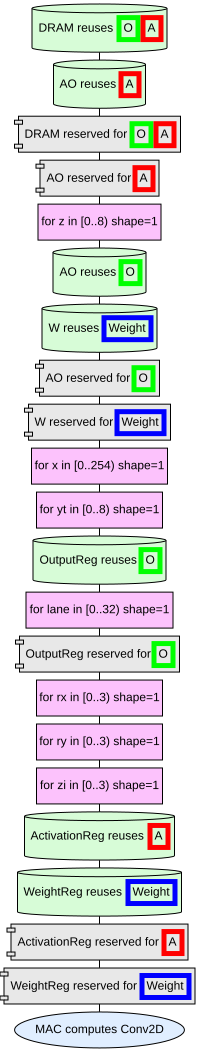

In [17]:
results

In [ ]:
from accelforge.util._setexpressions import InvertibleSet


def repair_invertible_sets(obj, seen=None):
    if seen is None:
        seen = set()

    if id(obj) in seen:
        return
    seen.add(id(obj))

    if isinstance(obj, InvertibleSet):
        private = getattr(obj, "__pydantic_private__", None)

        if private is None:
            private = {}
            object.__setattr__(obj, "__pydantic_private__", private)

        private.setdefault("_bits_per_value", None)

    if isinstance(obj, dict):
        children = list(obj.keys()) + list(obj.values())
    elif isinstance(obj, (list, tuple, set, frozenset)):
        children = obj
    elif hasattr(obj, "__dict__"):
        children = obj.__dict__.values()
    else:
        children = ()

    for child in children:
        repair_invertible_sets(child, seen)

In [ ]:
mapping = results.mapping()

repair_invertible_sets(mapping)

yaml_text = mapping.to_yaml()
print(yaml_text)

In [ ]:
arch